In [8]:
import pandas as pd
import numpy as np 
df = pd.read_csv(r"C:\Users\Ashutosh\Downloads\india_gender_pay_gap.csv")
print(df.head())
print(df.info())
df.isnull().sum()
df.duplicated().sum()


    category_type                category  pay_gap_percent  \
0  national_trend                 1993-94             30.0   
1  national_trend                 2011-12             35.0   
2  national_trend                 2017-18             33.0   
3  national_trend  Current (ILO estimate)             34.0   
4          sector           Manufacturing             56.0   

   women_earn_pct_of_men       year  \
0                   70.0    1993-94   
1                   65.0    2011-12   
2                   67.0    2017-18   
3                   66.0  2020-2024   
4                   44.0    2017-18   

                                                note source  
0             Early post-liberalization era estimate   NSSO  
1                       Gap widened over two decades   NSSO  
2                   Latest large-scale NSSO estimate   NSSO  
3  Headline national gender wage gap figure widel...    ILO  
4                  Largest sectoral gap in NSSO data   NSSO  
<class 'pandas.core.

np.int64(0)

In [9]:
# checking if there is nulll or duplicated value presented in the data set 
print(df.isnull().sum())
print(df.duplicated().sum())

category_type            0
category                 0
pay_gap_percent          0
women_earn_pct_of_men    0
year                     0
note                     0
source                   0
dtype: int64
0


In [10]:
# fixing the year 
def extract_year(value):
    value = str(value)
    # handle "Apr-Jun 2024" style
    if any(m in value for m in ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]):
        return int(value.split()[-1])
    # handle "2020-2024" (already a 4-digit range) -> take the later year
    if "-" in value and len(value.split("-")[-1]) == 4:
        return int(value.split("-")[-1])
    # handle "2017-18" or "2023-24" style (2-digit second half) -> expand to full year
    if "-" in value and len(value.split("-")[-1]) == 2:
        prefix = value.split("-")[0][:2]
        return int(prefix + value.split("-")[-1])
    # plain single year
    return int(value)

df["year_clean"] = df["year"].apply(extract_year)
df[["year", "year_clean"]].drop_duplicates()

,year,year_clean
0,1993-94,1994
1,2011-12,2012
2,2017-18,2018
3,2020-2024,2024
7,2023-2024,2024
11,Apr-Jun 2024,2024
14,2023-24,2024
17,2024,2024


In [12]:
df["category"] = df["category"].str.strip()
df["category_type"] = df["category_type"].str.strip()
df["source"] = df["source"].str.strip()

In [13]:
# changing the category type value 
label_map = {
    "national_trend": "National Trend Over Time",
    "sector": "By Sector / Industry",
    "region": "Urban vs Rural",
    "age_group": "By Age Group",
    "worker_type": "By Worker Type",
    "tech_seniority_overall": "Tech Sector — Seniority (Study 1)",
    "tech_seniority_itservices": "Tech Sector — Seniority (Study 2)",
}
df["category_type_label"] = df["category_type"].map(label_map)

In [14]:
# now saving the cleaned version of the dataset
df.to_csv("india_gender_pay_gap_cleaned.csv", index=False)

In [15]:
df

,category_type,category,pay_gap_percent,women_earn_pct_of_men,year,note,source,year_clean,category_type_label
0,national_trend,1993-94,30.00,70.00,1993-94,Early post-liberalization era estimate,NSSO,1994,National Trend Over Time
1,national_trend,2011-12,35.00,65.00,2011-12,Gap widened over two decades,NSSO,2012,National Trend Over Time
2,national_trend,2017-18,33.00,67.00,2017-18,Latest large-scale NSSO estimate,NSSO,2018,National Trend Over Time
3,national_trend,Current (ILO estimate),34.00,66.00,2020-2024,Headline national gender wage gap figure widel...,ILO,2024,National Trend Over Time
4,sector,Manufacturing,56.00,44.00,2017-18,Largest sectoral gap in NSSO data,NSSO,2018,By Sector / Industry
5,sector,Services,45.00,55.00,2017-18,Second largest sectoral gap,NSSO,2018,By Sector / Industry
6,sector,Agriculture,30.00,70.00,2017-18,"Smallest sectoral gap, though absolute wages v...",NSSO,2018,By Sector / Industry
7,sector,IT & Software,60.00,40.00,2023-2024,One of the most male-dominated high-pay sectors,Industry report (ChangeInContent),2024,By Sector / Industry
8,sector,Finance & Banking,50.00,50.00,2023-2024,Women underrepresented in senior finance roles,Industry report (ChangeInContent),2024,By Sector / Industry
9,sector,Education,25.00,75.00,2023-2024,"Narrower gap; feminized, lower-paying sector o...",Industry report (ChangeInContent),2024,By Sector / Industry


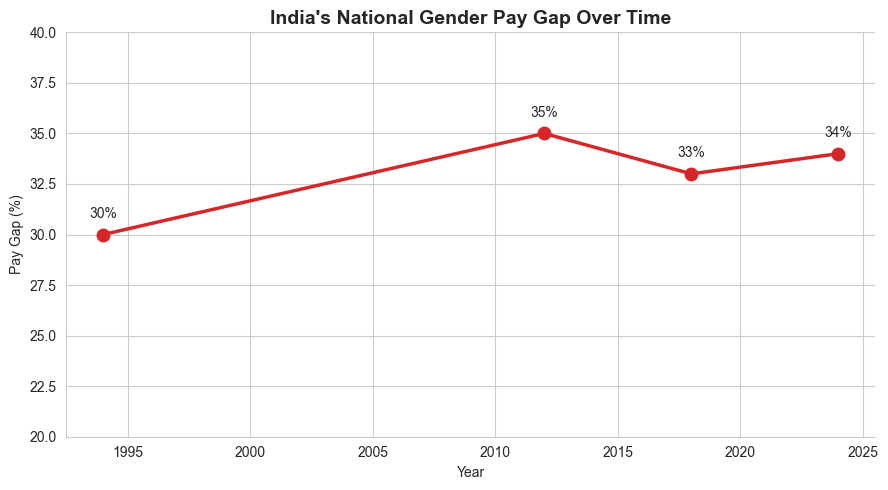

  conclusion - Shows the gap over years. It stays almost the same every year — not much change.


In [7]:
 # making a line chart 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load the cleaned dataset
df = pd.read_csv("india_gender_pay_gap_cleaned.csv")

# Filter to just the national trend rows
national = df[df['category_type'] == 'national_trend']
national_sorted = national.sort_values('year_clean')

# Build the line chart
plt.figure(figsize=(9, 5))
plt.plot(
    national_sorted['year_clean'], 
    national_sorted['pay_gap_percent'],
    marker='o', markersize=9, linewidth=2.5, color='#d62728'
)

# Add data labels above each point
for _, row in national_sorted.iterrows():
    plt.annotate(
        f"{row['pay_gap_percent']:.0f}%",
        (row['year_clean'], row['pay_gap_percent']),
        textcoords="offset points", xytext=(0, 12), ha='center', fontsize=10
    )

plt.title("India's National Gender Pay Gap Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Pay Gap (%)")
plt.ylim(20, 40)
sns.despine()
plt.tight_layout()
plt.show()
print("  conclusion - Shows the gap over years. It stays almost the same every year — not much change.")

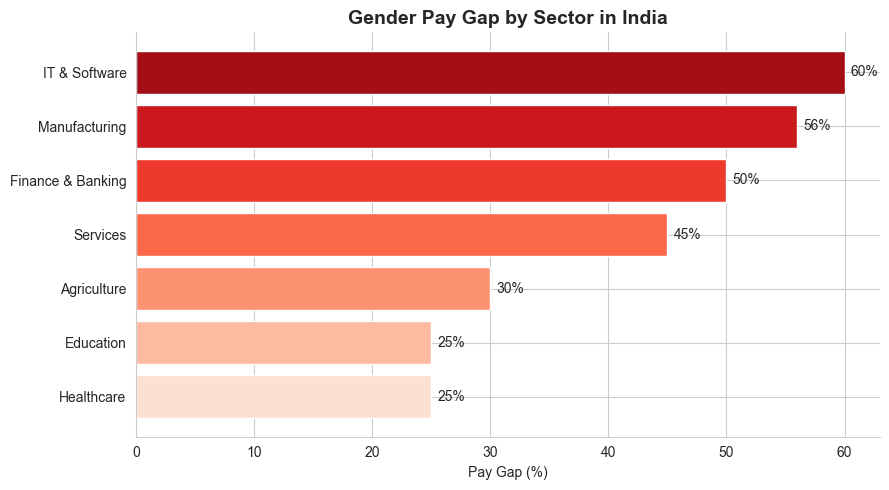

 conclusion - Just compares different job sectors. Some sectors have a bigger gap, some have a smaller gap.


In [8]:
# sector comparison- horizontal bar chart 
sector_df = df[df['category_type'] == 'sector']
sector_sorted = sector_df.sort_values('pay_gap_percent')

plt.figure(figsize=(9, 5))
bars = plt.barh(
    sector_sorted['category'], 
    sector_sorted['pay_gap_percent'],
    color=sns.color_palette("Reds", len(sector_sorted))
)

# Add value labels at the end of each bar
for bar, val in zip(bars, sector_sorted['pay_gap_percent']):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.0f}%", va='center')

plt.title("Gender Pay Gap by Sector in India", fontsize=14, fontweight='bold')
plt.xlabel("Pay Gap (%)")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()
print(" conclusion - Just compares different job sectors. Some sectors have a bigger gap, some have a smaller gap.")

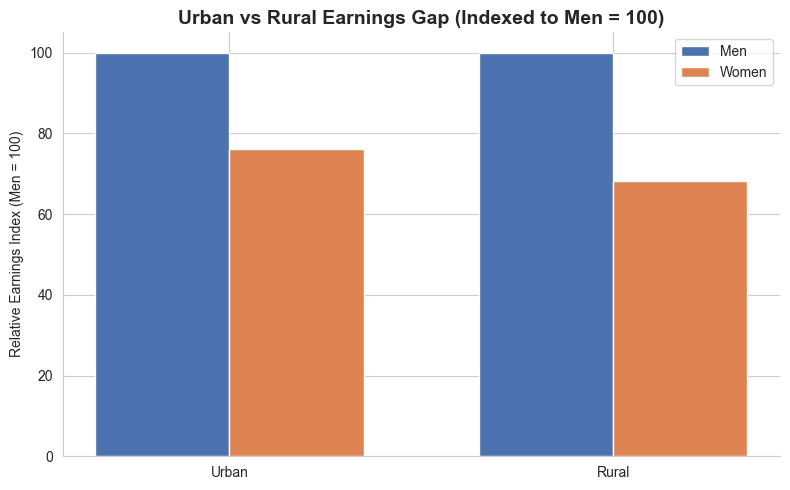

 conclusion - : Compares city vs village. Village has a bigger gap than city.


In [9]:
# urban vs rural 
region_df = df[df['category_type'] == 'region'].copy()
region_df['men_index'] = 100
region_df['women_index'] = region_df['women_earn_pct_of_men']

x = range(len(region_df))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], region_df['men_index'], width, label="Men", color='#4c72b0')
plt.bar([i + width/2 for i in x], region_df['women_index'], width, label="Women", color='#dd8452')

plt.xticks(list(x), region_df['category'])
plt.ylabel("Relative Earnings Index (Men = 100)")
plt.title("Urban vs Rural Earnings Gap (Indexed to Men = 100)", fontsize=14, fontweight='bold')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()
print(" conclusion - : Compares city vs village. Village has a bigger gap than city.")

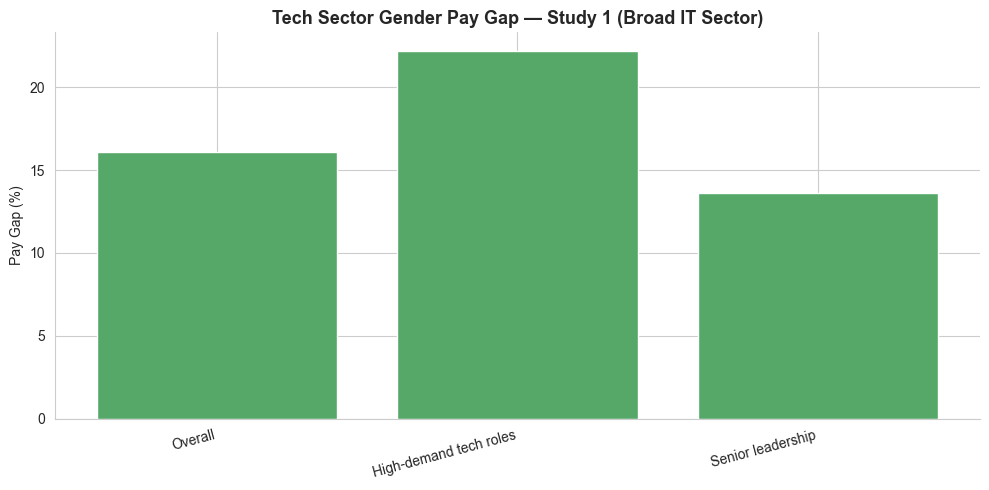

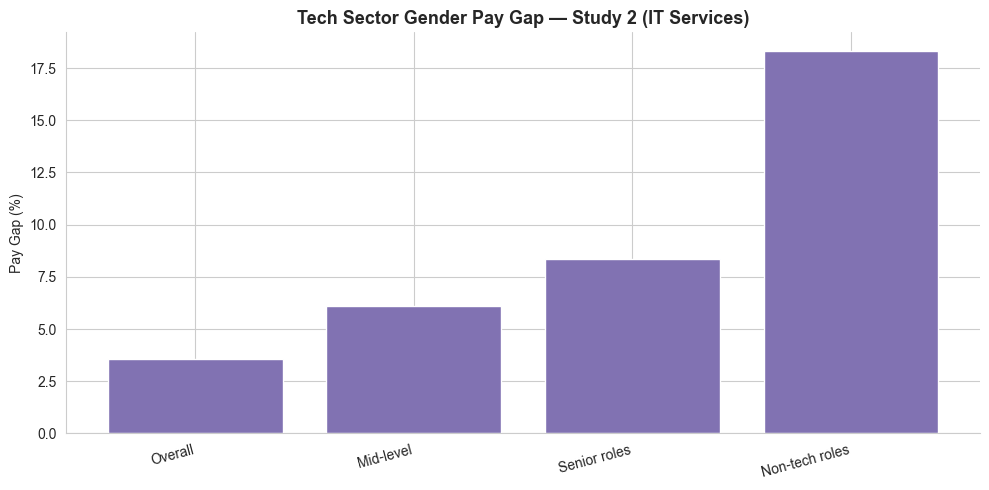

 conclusion - Shows the gap by job level (junior/senior). Gap usually gets bigger at higher levels. Two different studies gave slightly different numbers.
Note: the two studies show very different gap sizes (13-22% vs 3.5-18%),
likely due to different scope/methodology. Both are shown rather than picking one.


In [10]:
# tech sector seniority
tech1 = df[df['category_type'] == 'tech_seniority_overall'].copy()
tech2 = df[df['category_type'] == 'tech_seniority_itservices'].copy()

tech1['level'] = tech1['category'].str.replace('IT sector - ', '', regex=False)
tech2['level'] = tech2['category'].str.replace('IT Services - ', '', regex=False)

# Study 1
plt.figure(figsize=(10, 5))
plt.bar(range(len(tech1)), tech1['pay_gap_percent'], color='#55a868')
plt.xticks(range(len(tech1)), tech1['level'], rotation=15, ha='right')
plt.ylabel("Pay Gap (%)")
plt.title("Tech Sector Gender Pay Gap — Study 1 (Broad IT Sector)", fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

# Study 2
plt.figure(figsize=(10, 5))
plt.bar(range(len(tech2)), tech2['pay_gap_percent'], color='#8172b2')
plt.xticks(range(len(tech2)), tech2['level'], rotation=15, ha='right')
plt.ylabel("Pay Gap (%)")
plt.title("Tech Sector Gender Pay Gap — Study 2 (IT Services)", fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()
print(" conclusion - Shows the gap by job level (junior/senior). Gap usually gets bigger at higher levels. Two different studies gave slightly different numbers.")

print("Note: the two studies show very different gap sizes (13-22% vs 3.5-18%),")
print("likely due to different scope/methodology. Both are shown rather than picking one.")

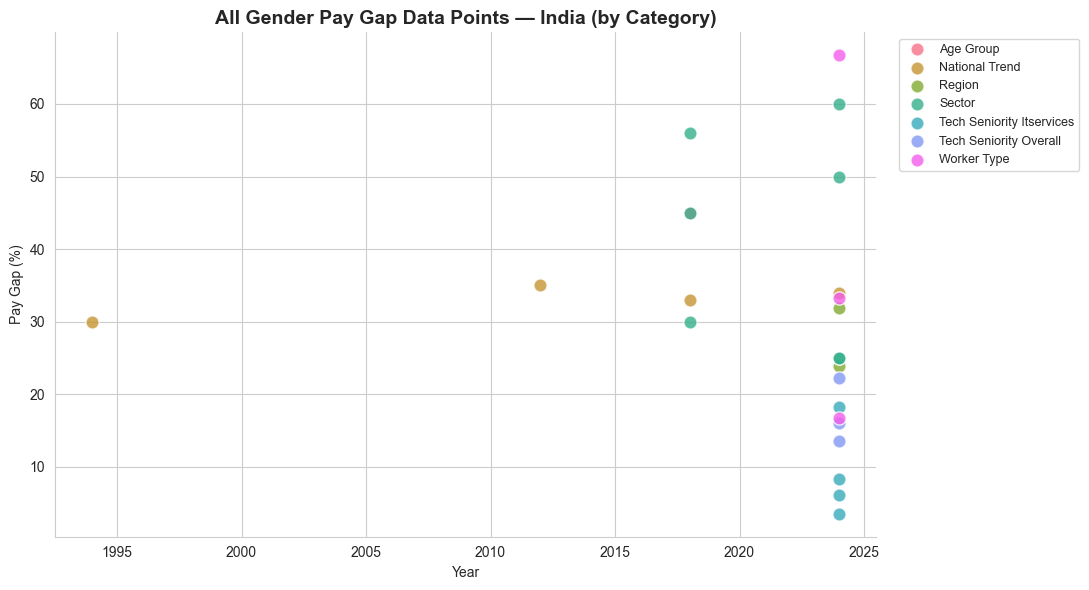

 conclusion -  Shows everything together. The dots don't follow the year — they follow the category (sector/job type). Meaning: the type of job matters more than the year.


In [11]:
# overview of full dataset
plt.figure(figsize=(11, 6))

palette = sns.color_palette("husl", df['category_type'].nunique())
for color, (cat, group) in zip(palette, df.groupby('category_type')):
    plt.scatter(
        group['year_clean'], group['pay_gap_percent'],
        label=cat.replace('_', ' ').title(), s=90, color=color, alpha=0.8, edgecolor='white'
    )

plt.xlabel("Year")
plt.ylabel("Pay Gap (%)")
plt.title("All Gender Pay Gap Data Points — India (by Category)", fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
print(" conclusion -  Shows everything together. The dots don't follow the year — they follow the category (sector/job type). Meaning: the type of job matters more than the year.")